# **Mutant Moneynall Project**

## **Importing the Dataset**

In [271]:
# Importing the useful libraries  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading in the Mutant Moneyball dataset
df = pd.read_csv("mutant_moneyball.csv")

# Checking to make sure the dataset loaded
df.head()   # will display the first five rows of the dataset


,Member,TotalValue60s_heritage,TotalValue70s_heritage,TotalValue80s_heritage,TotalValue90s_heritage,TotalValue60s_ebay,TotalValue70s_ebay,TotalValue80s_ebay,TotalValue90s_ebay,TotalValue60s_wiz,TotalValue70s_wiz,TotalValue80s_wiz,TotalValue90s_wiz,TotalValue60s_oStreet,TotalValue70s_oStreet,TotalValue80s_oStreet,TotalValue90s_oStreet
0,warrenWorthington,929056.0,154585.0,23957.0,960.0,23335.0,3362.0,583.0,97.0,"$7,913.00","$1,105.00",$226.00,$65.75,"$68,160.00","$7,360.00",$975.00,$123.00
1,hankMcCoy,929776.0,20705.0,6631.0,881.0,23377.0,1224.0,289.0,82.0,"$7,953.00",$851.00,$89.00,$38.50,"$68,390.00","$5,260.00",$431.00,$81.00
2,scottSummers,933616.0,188635.0,29240.0,739.0,23420.0,5431.0,1031.0,82.0,"$7,993.00","$1,979.00",$438.00,$39.25,"$68,590.00","$11,675.00","$1,427.00",$74.00
3,bobbyDrake,929776.0,154585.0,1514.0,874.0,23377.0,3362.0,70.0,93.0,"$7,953.00","$1,105.00",$48.00,$62.00,"$68,390.00","$7,360.00",$137.00,$108.00
4,jeanGrey,933616.0,179899.0,16868.0,1708.0,23420.0,4903.0,665.0,170.0,"$7,993.00","$1,679.00",$165.00,$108.00,"$68,590.00","$10,265.00",$822.00,$189.00


## **Data Cleaning and Tidy Process**

#### **Using .melt()**
The purpose using .melt() in pandas is to transform the data from wide to long format, which is a principle of tidy data. It take multiple columns ans converts them into two columns, one for the variable name, and one for the value. This is important becasue each variable should have its own column, each observation a row, and each unit in a cell. 

In [272]:
# Converting the data from wide format to long format using .melt()
df_tidy = df.melt(
    id_vars = "Member",         # Columns to keep fixed, in this dataset, "Members" are the identifiers
    var_name = "Variable",      # Name for the new column that holds the former column names; "Variable" holds total value, decade, and source
    value_name = "Value"        # Name for the New column that will hold values for the melted columns; "Value" will hold the card prices
)

# Checking the new format
df_tidy.head()

,Member,Variable,Value
0,warrenWorthington,TotalValue60s_heritage,929056.0
1,hankMcCoy,TotalValue60s_heritage,929776.0
2,scottSummers,TotalValue60s_heritage,933616.0
3,bobbyDrake,TotalValue60s_heritage,929776.0
4,jeanGrey,TotalValue60s_heritage,933616.0


#### **Using .str.split()**
Sometimes the .melt() method combines multiple values in one column. This is when .str.split() is used to break the strings into multiple columns. This allows us to clean and analyze the data further. 

In [273]:
# There are still multiple values within the Variable column that need to be split 
# Make Decade and Source their own columns
df_tidy[['Decade', 'Source']] = df_tidy['Variable'].str.split("_", expand = True)

# Checking the new format
df_tidy.head()

,Member,Variable,Value,Decade,Source
0,warrenWorthington,TotalValue60s_heritage,929056.0,TotalValue60s,heritage
1,hankMcCoy,TotalValue60s_heritage,929776.0,TotalValue60s,heritage
2,scottSummers,TotalValue60s_heritage,933616.0,TotalValue60s,heritage
3,bobbyDrake,TotalValue60s_heritage,929776.0,TotalValue60s,heritage
4,jeanGrey,TotalValue60s_heritage,933616.0,TotalValue60s,heritage


#### **Using .str.replace()**
Using .str.replace() removes or replaces unwanted text in a column. THis helps to avoid messy values, keeping information clean and consistent. We can ensure that we have relevant information, and that the data is in the correct type ffor future calculations. 

In [274]:
# Need to clean the Decade Column by removing the "TotalValue" portion
df_tidy['Decade'] = df_tidy['Decade'].str.replace('TotalValue','')

# Checking the new format
df_tidy.head()

,Member,Variable,Value,Decade,Source
0,warrenWorthington,TotalValue60s_heritage,929056.0,60s,heritage
1,hankMcCoy,TotalValue60s_heritage,929776.0,60s,heritage
2,scottSummers,TotalValue60s_heritage,933616.0,60s,heritage
3,bobbyDrake,TotalValue60s_heritage,929776.0,60s,heritage
4,jeanGrey,TotalValue60s_heritage,933616.0,60s,heritage


#### **Other tidying steps**
Below, further steps were taken to clean the names in the Member column, as well as the numbers in the Value column. The names were rearranged from first to last, unique characters eliminated from the Value column, and all numbers in the Value column were converted to numeric. These steps were necessary to make accurate and logical visualizations. 

In [275]:
# Cleaning the names 
df_tidy["Member"] = (
    df_tidy["Member"]
    .str.replace(r'([a-z])([A-Z])', r'\1 \2', regex=True)  # Adds spaces between every lowercase and capital letter
    .str.replace("Mc ", "Mc", regex=False)                 # Fixes McCoy issue
    .str.title()                                           # Capitalizes names
)

# Cleaning the characters in the Value column
df_tidy['Value'] = (
    df_tidy['Value']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)           # Removes $ and commas
    .str.strip()                                     # Removes extra spaces
)

df_tidy['Value'] = pd.to_numeric(df_tidy['Value'], errors='coerce')     # Converts all values to numeric, which is better for visualization building

# Cheack formatting 
df_tidy.head()

,Member,Variable,Value,Decade,Source
0,Warren Worthington,TotalValue60s_heritage,929056.0,60s,heritage
1,Hank Mccoy,TotalValue60s_heritage,929776.0,60s,heritage
2,Scott Summers,TotalValue60s_heritage,933616.0,60s,heritage
3,Bobby Drake,TotalValue60s_heritage,929776.0,60s,heritage
4,Jean Grey,TotalValue60s_heritage,933616.0,60s,heritage


In [276]:
# Keep only the clean columns
df_tidy[['Member','Decade','Source','Value']]       # Eliminates the Variable column

# Rename the fully cleaned dataset 
df2_tidy = df_tidy[['Member','Decade','Source','Value']]

# Check the formatting 
df2_tidy.head()

,Member,Decade,Source,Value
0,Warren Worthington,60s,heritage,929056.0
1,Hank Mccoy,60s,heritage,929776.0
2,Scott Summers,60s,heritage,933616.0
3,Bobby Drake,60s,heritage,929776.0
4,Jean Grey,60s,heritage,933616.0


## **Visualizations**

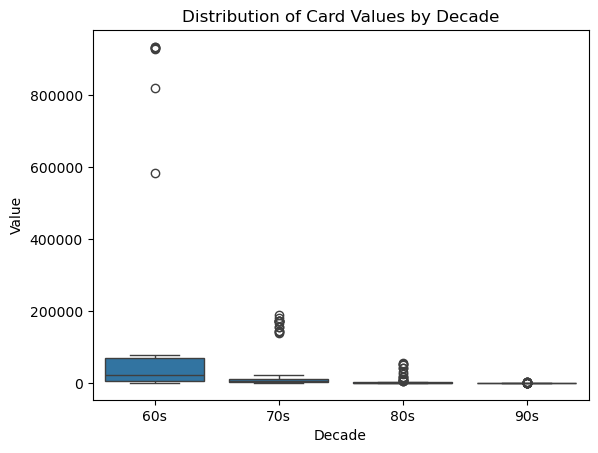

In [277]:
# Boxplot to show the overall distribution by decade 
plt.figure()

sns.boxplot(
    data=df2_tidy,
    x="Decade", 
    y="Value")
plt.title("Distribution of Card Values by Decade")
plt.show()

#### **Key takeaway from the boxplot**
The boxplot groups the data by decade, and summarizes the spread and median of card value per decade. The 60s cards, as shown by the higher box, tend to be more valuable. A histogram depicting the value of card in only the 60s decade is shown below. 

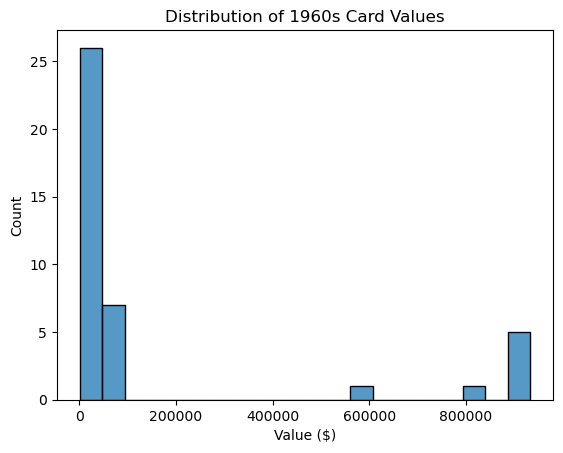

In [278]:
# Creating a histogram for the 60s decade
df_60s = df2_tidy[df2_tidy["Decade"] == "60s"]

plt.figure()
sns.histplot(data=df_60s, x="Value", bins=20)

plt.title("Distribution of 1960s Card Values")
plt.xlabel("Value ($)")
plt.ylabel("Count")

plt.show()



#### **Diving deeper into the 60s**
The boxplot alinged with the 60s decade is noticibly higher in value than the other decades, and has much higher outliers. This suggests that a few cards are worth significantly more than others. This aligns with the real-world applications of collecting cards, as traditionally, the older cards are more rare, and thus, more valuable. Cards from the 60s are scarce today, and are often lost or deconstructed over time, which adds to the rarity. However, because these outliers are so large, the y-axis is stretched, which makes the other decades apper much smaller. 

The histogram zooms further into the card values during the 1960s. The majority of cards are not very high in value, sitting in the ~$0-$140,000 range. However, there is a group of cards from the 1960s worth ~$600,000, and a significant number of cards valued above $800,000. This group represents the extreme outliers in the boxplot, and accounts for the rarity of acquiring one of these cards. 


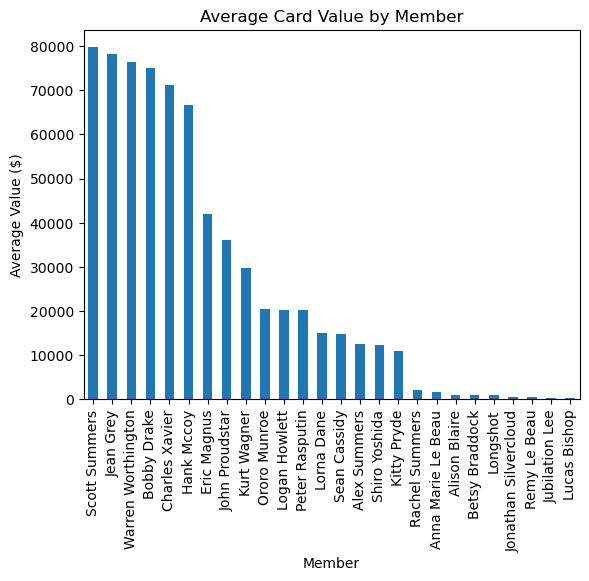

In [279]:
# Bar chart for average card value for each member

# Find average values 
avg_values = (
    df2_tidy.groupby("Member")["Value"]     # Groups each member by value, combines across Decade and Source
    .mean()                                 # Calculates the average
    .sort_values(ascending=False))          # Sorts from highest to lowest

# Create the bar chart 
plt.figure()

avg_values.plot(kind="bar")
plt.title("Average Card Value by Member")
plt.ylabel("Average Value ($)")
plt.xticks(rotation=90)
plt.show()

#### **Key takeaway from the bar graph** 
The bar chart displays the average card value per member across all decades and sources. The data was grouped by Member, which groups all rows for each character, so that the different decades and sources are combined per member. Then, the mean was calculated the average value for each character. This allows for the comparison of overall card value across all members. The discrepancy between members is large from highest to lowest. Scott Summers has the highest, and Lucas Bishop the lowest. 

## **Pivot tables**
#### **Diving deeper into card value**


The Bar graph above took the average of all the value records per card. One important consideration moving forward is that each card has multiple records of values, as demonstrated below. 

In [280]:
# Demonstrate that each memebr has multiple values 
df2_tidy.groupby("Member")["Value"].count()      # Displays how many value records each member has

Member
Alex Summers            16
Alison Blaire            8
Anna Marie Le Beau       8
Betsy Braddock           8
Bobby Drake             16
Charles Xavier          16
Eric Magnus             16
Hank Mccoy              16
Jean Grey               16
John Proudstar           4
Jonathan Silvercloud     8
Jubilation Lee           8
Kitty Pryde              4
Kurt Wagner              8
Logan Howlett           12
Longshot                 4
Lorna Dane              16
Lucas Bishop             4
Ororo Munroe            12
Peter Rasputin          12
Rachel Summers           8
Remy Le Beau             4
Scott Summers           16
Sean Cassidy            16
Shiro Yoshida           12
Warren Worthington      16
Name: Value, dtype: int64

Knowing this, we can look at the maximum value recorded per card. 

In [281]:
# Show the maximum value for each member 
pivot_table = df2_tidy.pivot_table(
    values="Value",         # Column to populate the new DataFrame's values 
    index="Member",         # Column to use as the new row labels (unique identifier)
    aggfunc="max"           # Matematical function, selects the largest value in the group
)

pivot_table.head(10)        # Displays the top ten Members who have paid the largest price

,Value
Member,
Alex Summers,144946.0
Alison Blaire,7198.0
Anna Marie Le Beau,10730.0
Betsy Braddock,5573.0
Bobby Drake,929776.0
Charles Xavier,819537.0
Eric Magnus,582934.0
Hank Mccoy,929776.0
Jean Grey,933616.0


#### **Key takeaway from the pivot table**
By showing the largest value paid by each member, we can see the willingness to pay for dertain cards. However, further exploration might be done to show trends over time, or how value changed per card over the decades. This data can be used for future decsion making regarding finicial implications around purchasing and sales, as shown in the heatmap below. 

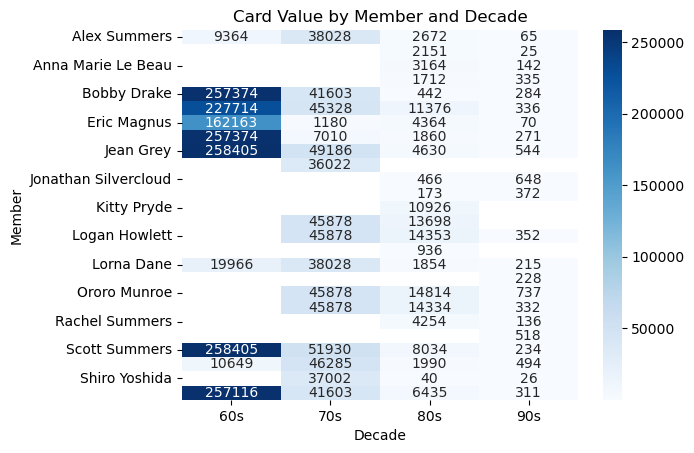

In [282]:
pivot = df2_tidy.pivot_table(
    values="Value",                 # Column to populate the new DataFrame's values 
    index="Member",                 # Column to use as the new row labels (unique identifier)
    columns="Decade",               # Column whose unique values will beocme the column headers 
    aggfunc="mean")                 # Matematical function, finds the mean per Member 

plt.figure()
sns.heatmap(pivot,                  # Name of pivot table
            annot=True,             # Adds numbers in each cell
            fmt = ".0f",            # Rounds to whole numbers 
            cmap = "Blues")         # Color

plt.title("Card Value by Member and Decade")
plt.show()

#### **Key takeaway from the heatmap**
Looking at the heatmap, we can see that there are multiple values per card, and the data is displayed with Members as the rows, and Decade as the columns. We can see how card values change over time for each Member, like a ranking. For example, looking at Scott Summers again, we can now see that while he was very valuable in the 1960s, the value of his card has decreased over time. This aligns with the information in the box plot as well, as older cards are more valuable than newer cards. 

## **Conclusion**


This project dispalys the importance of Tidy Data principles in order to transform and analyze data. By restructuing the data so that each variable ahs a column, each observation forms a row, and each unit is clearly defined in a cell, the data can be manipulated and explored. The Mutant Moneyball dataset revealed the history of the value of x-Men trading cards, and specifically, that older cards tend ot be more valuable. There are also certain memebers that hold higher values than others. This was shown through the various visualizations and bar charts. If I were to expand this project further, I would like to analyze the Source column more in the future. 